<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [26]:
!pip install pandas

In [27]:
!pip install matplotlib

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [29]:
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [30]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [31]:
df.duplicated().sum()

np.int64(10)

In [32]:
# Remove duplicates
df_clean = df.drop_duplicates()

#Verify removal
df_clean.duplicated().sum()

np.int64(0)

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [33]:
df_clean['CodingActivities'].isnull().sum()

np.int64(10971)

This indicates that a large number of respondents did not provide information about their coding activities.

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [34]:
df_clean['CodingActivities'] = df_clean['CodingActivities'].ffill()

#Verify imputation worked
df_clean['CodingActivities'].isnull().sum()

np.int64(0)

**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


In [35]:
df_clean['ConvertedCompYearly'].isnull().sum()

np.int64(42002)

Since compensation data is:

highly skewed
contains outliers

👉 Median is the best choice (more robust than mean)

In [36]:
median_value = df_clean['ConvertedCompYearly'].median()

df_clean['ConvertedCompYearly'] = df_clean['ConvertedCompYearly'].fillna(median_value)

# Verify
df_clean['ConvertedCompYearly'].isnull().sum()

np.int64(0)

### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [37]:
df_clean[['CompTotal', 'ConvertedCompYearly']].head()

,CompTotal,ConvertedCompYearly
0,NaN,65000.0
1,NaN,65000.0
2,NaN,65000.0
3,NaN,65000.0
4,NaN,65000.0


The compensation-related columns were examined, and ConvertedCompYearly was selected for normalization. The CompTotal column contained many missing values and was not suitable for analysis. ConvertedCompYearly was already standardized and imputed, making it the appropriate variable for normalization in this task.

##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [38]:
# Apply Min-Max scaling
df_clean['ConvertedCompYearly_MinMax'] = (
    df_clean['ConvertedCompYearly'] - df_clean['ConvertedCompYearly'].min()
) / (
    df_clean['ConvertedCompYearly'].max() - df_clean['ConvertedCompYearly'].min()
)

In [39]:
#Verify results
df_clean[['ConvertedCompYearly', 'ConvertedCompYearly_MinMax']].head()

,ConvertedCompYearly,ConvertedCompYearly_MinMax
0,65000.0,0.003998
1,65000.0,0.003998
2,65000.0,0.003998
3,65000.0,0.003998
4,65000.0,0.003998


In [40]:
# Check range
df_clean['ConvertedCompYearly_MinMax'].min(), df_clean['ConvertedCompYearly_MinMax'].max()

(np.float64(0.0), np.float64(1.0))

Min-Max scaling was applied to the ConvertedCompYearly column to normalize compensation values into a range between 0 and 1. This transformation ensures that all values are on a comparable scale, making it easier to analyze and compare data without being affected by large numerical differences or outliers.

##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [41]:
# Apply Z-score formula
df_clean['ConvertedCompYearly_Zscore'] = (
    df_clean['ConvertedCompYearly'] - df_clean['ConvertedCompYearly'].mean()
) / df_clean['ConvertedCompYearly'].std()

In [42]:
# Verify results
df_clean[['ConvertedCompYearly', 'ConvertedCompYearly_Zscore']].head()

,ConvertedCompYearly,ConvertedCompYearly_Zscore
0,65000.0,-0.067513
1,65000.0,-0.067513
2,65000.0,-0.067513
3,65000.0,-0.067513
4,65000.0,-0.067513


In [43]:
# Check correctness (important validation)
df_clean['ConvertedCompYearly_Zscore'].mean()
df_clean['ConvertedCompYearly_Zscore'].std()

np.float64(1.0)

Min-Max → bounds data between 0 and 1
Z-score → centers data around 0 with unit variance
Both are correct, but used in different analytical contexts

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


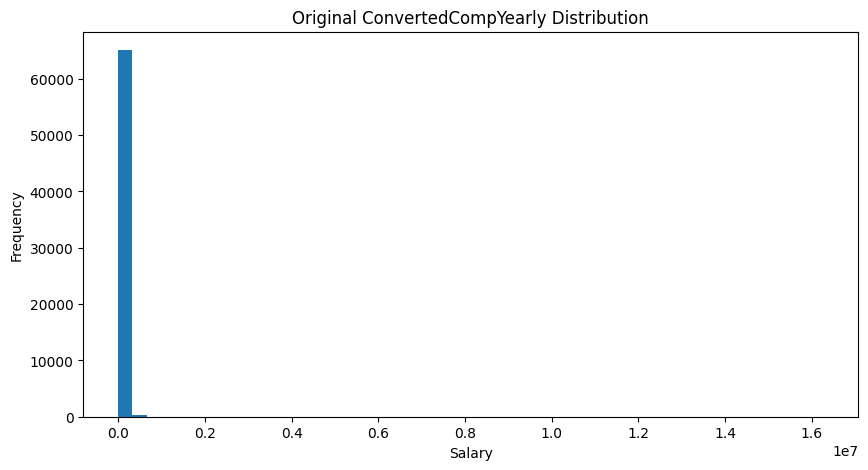

In [44]:
import matplotlib.pyplot as plt

# Original data
plt.figure(figsize=(10,5))
df_clean['ConvertedCompYearly'].plot(kind='hist', bins=50)

plt.title("Original ConvertedCompYearly Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

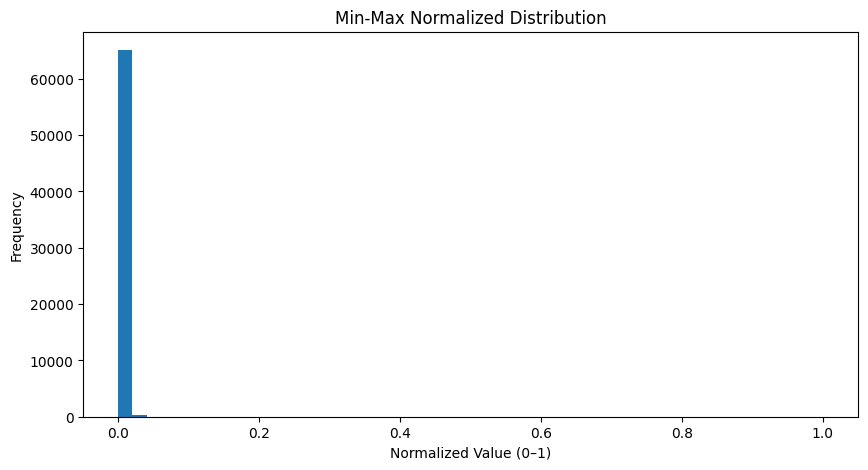

In [45]:
# Min-Max Normalized data
plt.figure(figsize=(10,5))
df_clean['ConvertedCompYearly_MinMax'].plot(kind='hist', bins=50)

plt.title("Min-Max Normalized Distribution")
plt.xlabel("Normalized Value (0–1)")
plt.ylabel("Frequency")
plt.show()

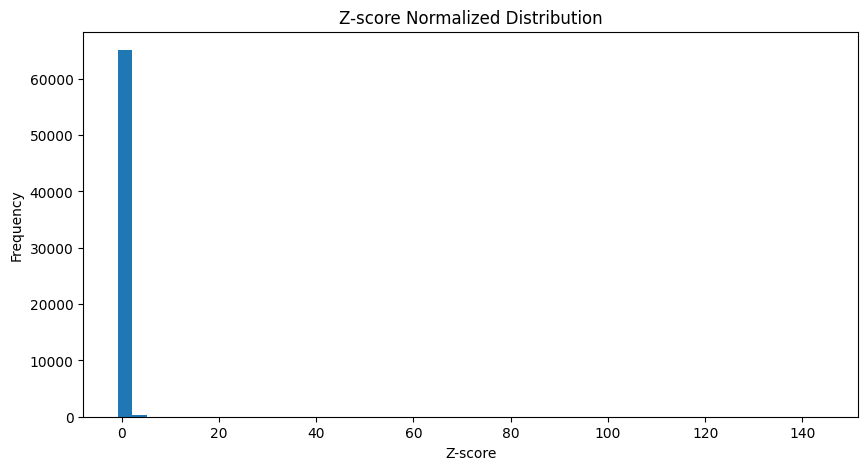

In [46]:
# Z-score Normalized data
plt.figure(figsize=(10,5))
df_clean['ConvertedCompYearly_Zscore'].plot(kind='hist', bins=50)

plt.title("Z-score Normalized Distribution")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.show()

The distribution of ConvertedCompYearly was visualized before and after normalization using Min-Max scaling and Z-score standardization. The original data showed a highly right-skewed distribution. Min-Max scaling preserved the shape of the distribution while compressing values into a 0–1 range. Z-score normalization centered the data around zero with a standard deviation of one, making it suitable for statistical comparisons. These transformations help standardize the data for further analysis and modeling.

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
